Este notebook realiza uma EDA (Exploratory Data Analysis) focada no dataset `train_identity.csv`.  O objetivo principal foi:

- compreender a estrutura do dataset de identidade;
- analisar valores ausentes;
- investigar variáveis relacionadas ao dispositivo e autenticação;
- relacionar os dados de identidade com a variável alvo (isFraud).


#### 3. Importação e carregamento dos dados

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 200)
sns.set_style('whitegrid')

In [21]:
identify = pd.read_csv('../data/train_identity.csv')

In [22]:
print(identify.shape)
identify.head()

(144233, 41)


,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NotFound,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,NaN,100.0,NotFound,49.0,-300.0,New,NotFound,166.0,NaN,621.0,500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,iOS 11.1.2,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,52.0,NaN,Found,Found,121.0,NaN,410.0,142.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,NaN,100.0,NotFound,52.0,NaN,New,NotFound,225.0,NaN,176.0,507.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,NaN,-300.0,Found,Found,166.0,15.0,529.0,575.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,Mac OS X 10_11_6,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


O dataset contém 144.223 registros e 41 atributos, sendo 23 variáveis numéricas (`float64`), 17 variáveis categóricas (`str`) e 1 identificador (`TransactionID`). Esse número é significativamente menor que o dataset transacional, indicando que: nem todas as transações possuem informações de identidade associadas. Além disso, observa-se um nível extremamente elevado de missings values em diversas features. 

*Observação:* O dataset `train_identity` funciona como uma tabela complementar ao train_transaction, sendo necessário realizar merge via `TransactionID`.

##### 3.1 Estrutura geral do dataset

In [ ]:
# 3.1.1 Tipos de Variáveis
identify.info()

<class 'pandas.DataFrame'>
RangeIndex: 144233 entries, 0 to 144232
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionID  144233 non-null  int64  
 1   id_01          144233 non-null  float64
 2   id_02          140872 non-null  float64
 3   id_03          66324 non-null   float64
 4   id_04          66324 non-null   float64
 5   id_05          136865 non-null  float64
 6   id_06          136865 non-null  float64
 7   id_07          5155 non-null    float64
 8   id_08          5155 non-null    float64
 9   id_09          74926 non-null   float64
 10  id_10          74926 non-null   float64
 11  id_11          140978 non-null  float64
 12  id_12          144233 non-null  str    
 13  id_13          127320 non-null  float64
 14  id_14          80044 non-null   float64
 15  id_15          140985 non-null  str    
 16  id_16          129340 non-null  str    
 17  id_17          139369 non-null  float64


In [ ]:
# 3.1.2 Valores ausentes
missing_identity = (
    identify
    .isnull()
    .mean()
    .sort_values(ascending=False)
)

missing_identity.head(20)

id_24         0.967088
id_25         0.964419
id_07         0.964259
id_08         0.964259
id_21         0.964231
id_26         0.964204
id_23         0.964162
id_27         0.964162
id_22         0.964162
id_18         0.687221
id_04         0.540161
id_03         0.540161
id_33         0.491871
id_10         0.480521
id_09         0.480521
id_30         0.462224
id_32         0.462079
id_34         0.460560
id_14         0.445037
DeviceInfo    0.177262
dtype: float64

Diversas variáveis apresentam níveis extremamente elevados de ausência, com algumas features possuindo mais de 96% de missing values. Em sistemas antifraude, ausência de informação frequentemente possui significado operacional e comportamental, portanto, esses dados não poderão ser simplesmente descartados. Contudo, esssas features devem ser avalidas com cuidado antes da modelagem, pois podem trazer o efeito oposto ao que buscamos introduzindo ruído ou pouca contribuição estatística.

As features - `id_24`, `id_25`, `id_07`, `id_08`, `id_21`, `id_22`, `id_23`, `id_26`, `id_27` possuem mais de 96% de valores ausentes, sugerindo algumas hipóteses: 
    - essas informações são coletadas apenas em cenários específicos
    - determinadas verificações podem ocorrer apenas em alguns fluxos
    - certos mecanismos de autenticação são raramente acionados.

Atributos como - `id_30`, `id_32`, `id_33`e `id_34`- apresentam entre 45% a 50% de ausência, podemos pensar que essas variáveis podem estar relacionadas ao sistema operacional, resolução de tela, autenticação, informações de ambiente.

A variável `DeviceInfo` representa aproximadamente 17.7% de missing values (o menor valor dentre as outras), sugerindo que informações relacionadas ao dispositivo estão disponíveis em boa parte das transações com identidade associada.

A disponibilidade ou ausência de determinadas informações pode:

 - indicar diferentes fluxos de autenticação
 - refletir limitações do dispositivo
 - revelar comportamento suspeito
 - sugerir tentativas de ocultação de identidade

Por esse motivo, futuras etapas de feature engineering poderão explorar:
 - flags de missing
 - quantidade de informações disponíveis
 - padrões de ausência por grupo de features
 - relações entre missing e fraude

##### 3.2 Merge com target

Faremos um merge temporário com target, porque `train_identity` NÃO possui `isFraud` contudo precisamos comparar fraude vs não fraude

In [ ]:
# 3.2.1 Carregando os dados de transação
transaction = pd.read_csv("../data/train_transaction.csv", usecols=["TransactionID", "isFraud"])

In [ ]:
# 3.2.2 Unindo os dados de identificação e transação através do TransactionID
identify_df = identify.merge(transaction, on="TransactionID", how="left")

In [ ]:
# 3.2.3 Criando uma nova coluna para contar o número de valores ausentes em cada linha
identify_df["missing_count"] = (
    identify_df
    .isnull()
    .sum(axis=1)
)

In [62]:
identify_df["isFraud"].value_counts(normalize=True) * 100

isFraud
0    92.152975
1     7.847025
Name: proportion, dtype: float64

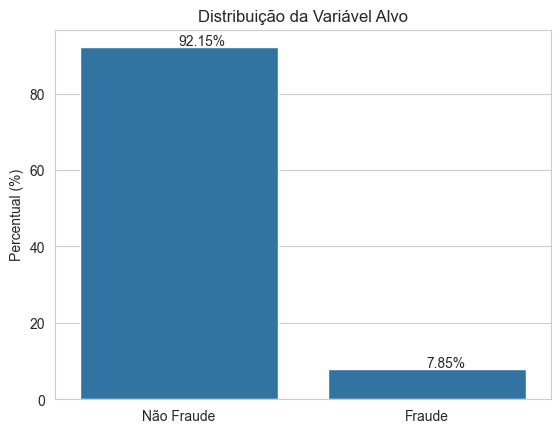

In [63]:
fraud_dist = (
    identify_df["isFraud"]
    .value_counts(normalize=True)
    * 100
)

ax = sns.barplot(
    x=["Não Fraude", "Fraude"],
    y=fraud_dist.values
)

plt.title("Distribuição da Variável Alvo")
plt.ylabel("Percentual (%)")

for i, v in enumerate(fraud_dist.values):
    ax.text(i, v + 0.5, f"{v:.2f}%")

plt.show()

#### 3.3 Missing por classe alvo

Nesta etapa, investigamos se a quantidade de valores ausentes apresenta comportamento diferente entre transações fraudulentas e legítimas.

Text(0.5, 1.0, 'Distribuição de Valores Ausentes por Classe')

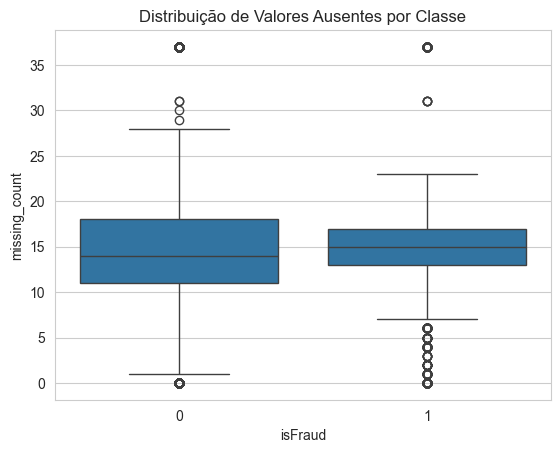

In [61]:
# 3.3.1 Boxplot missing_count vs isFraud
sns.boxplot(
    data = identify_df,
    x='isFraud',
    y='missing_count'
)

plt.title(
    "Distribuição de Valores Ausentes por Classe"
)

O boxplot compara a distribuição da quantidade de valores ausentes (missing_count) entre transações legítimas (isFraud = 0) e fraudulentas (isFraud = 1).

Observa-se que as transações fraudulentas apresentam mediana ligeiramente superior de valores ausentes em relação às transações não fraudulentas. Isso sugere que operações classificadas como fraude tendem a possuir menos informações disponíveis ou ambientes com maior ocultação de dados.

Além disso, as transações legítimas apresentam maior dispersão dos dados, indicando maior variabilidade na quantidade de atributos ausentes. Já as transações fraudulentas demonstram distribuição mais concentrada, sugerindo um padrão mais consistente de ausência de informações.

Também é possível observar a presença de outliers em ambos os grupos, indicando casos extremos com grande quantidade de variáveis ausentes. Em cenários antifraude, esse comportamento pode estar relacionado a dispositivos incomuns, anonimização de ambiente, limitações de coleta de dados ou tentativas de mascaramento de identidade.

Dessa forma, a quantidade de atributos ausentes pode representar um sinal relevante para modelos de Machine Learning voltados à detecção de fraude, justificando a criação da feature missing_count durante a etapa de engenharia de atributos. 

#### 3.4  Variáveis com maior ausência em fraudes

O gráfico abaixo apresenta as variáveis cujo percentual de valores ausentes é maior em transações fraudulentas quando comparadas às não fraudulentas.

<Figure size 1200x800 with 0 Axes>

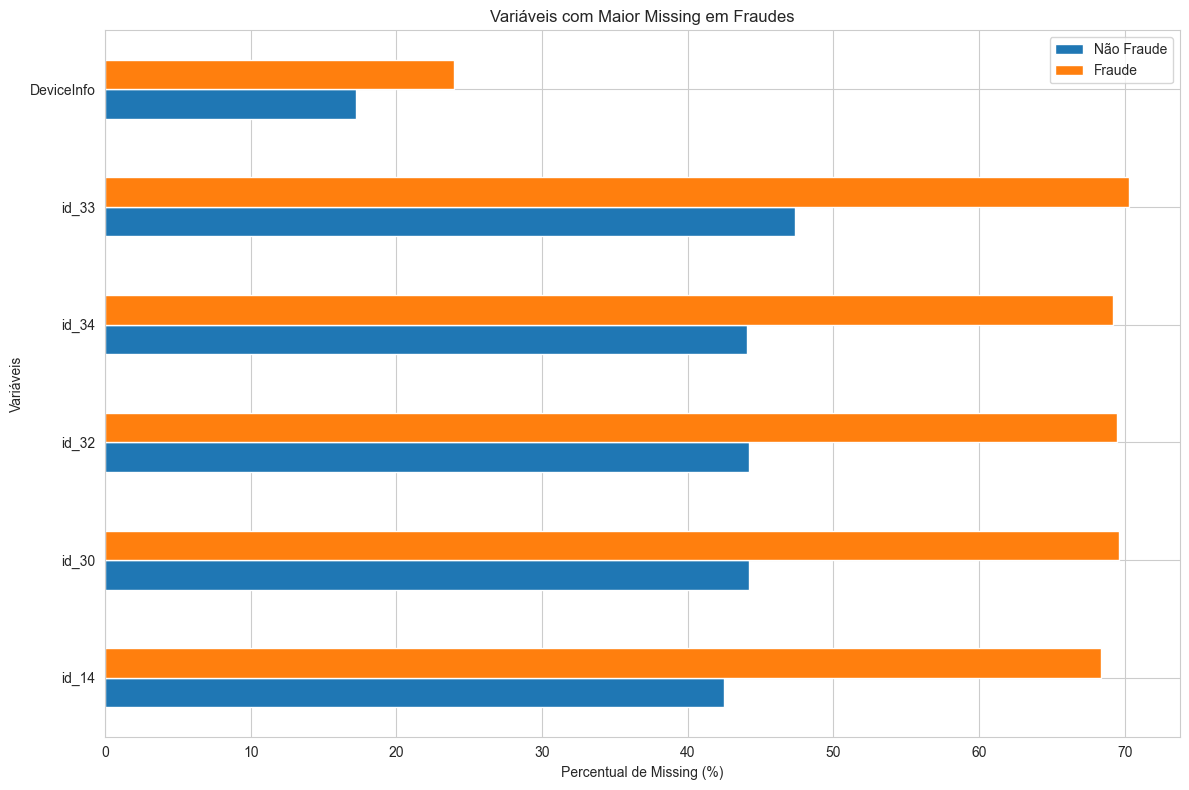

In [ ]:
# 3.3.2  Gráfico: features com maior missing em fraudes
# Percentual de missing por classe
missing_by_fraud = (
    identify_df
    .groupby("isFraud")
    .apply(lambda x: x.isnull().mean() * 100)
).T

# Diferença entre fraude e não fraude
missing_by_fraud["diff"] = (
    missing_by_fraud[1] - missing_by_fraud[0]
)

# Mantendo apenas variáveis onde fraude > não fraude
top_missing_fraud = (
    missing_by_fraud[
        missing_by_fraud["diff"] > 0
    ]
    .sort_values("diff", ascending=False)
    .head(15)
)

# Criando gráfico
plt.figure(figsize=(12,8))

ax = top_missing_fraud[[0,1]].plot(
    kind="barh",
    figsize=(12,8)

)

# Títulos
plt.title("Variáveis com Maior Missing em Fraudes")
plt.xlabel("Percentual de Missing (%)")
plt.ylabel("Variáveis")

plt.legend([
    "Não Fraude",
    "Fraude"
])

plt.tight_layout()
plt.show()

#### 3.5 Distribuição de fraude por tipo de dispositivo - `DeviceType`

Nesta análise, investigamos como as fraudes se distribuem entre dispositivos desktop e mobile.

In [ ]:
# 3.5.1 Analisando a distribuição da variável DeviceType
identify_df["DeviceType"].value_counts(normalize=True)

DeviceType
desktop    0.604822
mobile     0.395178
Name: proportion, dtype: float64

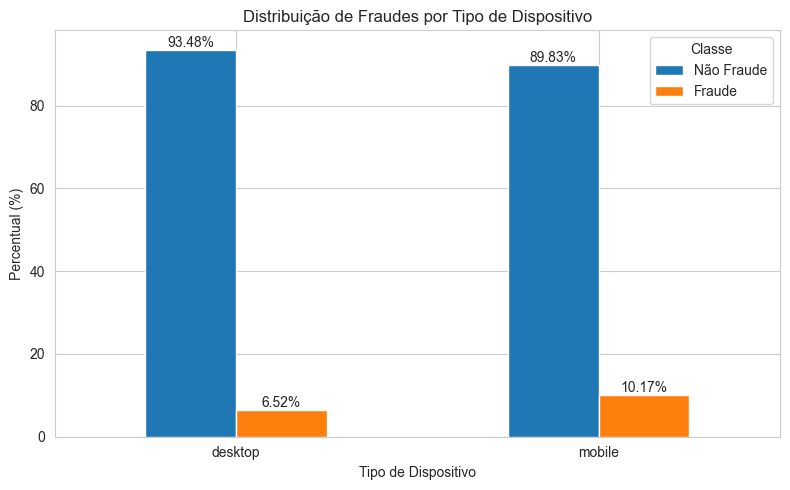

In [ ]:
# 3.5.2 Analisando a relação entre DeviceType e isFraud

# Tabela proporcional
fraud_device = pd.crosstab(
    identify_df["DeviceType"],
    identify_df["isFraud"],
    normalize="index"
) * 100

# Renomeando colunas para facilitar leitura
fraud_device.columns = ["Não Fraude", "Fraude"]

# Criando gráfico
ax = fraud_device.plot(
    kind="bar",
    figsize=(8, 5)
)

# Personalização
plt.title("Distribuição de Fraudes por Tipo de Dispositivo")
plt.xlabel("Tipo de Dispositivo")
plt.ylabel("Percentual (%)")
plt.xticks(rotation=0)

# Mostrar valores nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')

plt.legend(title="Classe")
plt.tight_layout()
plt.show()

Através do gráfico acima, podemos verificar que transações fraudulentas tem ocorrido em maior quantidade em ambientes mobile, apresentando cerca de 10.17% das operações realizadas em dispositivos eletrônicos. Porém operações fraudulentas em ambiente desktop ainda continuam acontecendo, mesmo que numa margem menor (6.52%). 

Os campos id_30 e id_31 apresentam, no conjunto de dados original, uma grande quantidade de valores altamente fragmentados e inconsistentes, como versões específicas de navegadores e sistemas operacionais (por exemplo, “mobile safari 13.0”, “chrome 63.0”, “samsung browser”, “windows 10” e “ios 13.3.1”). Essa granularidade excessiva aumenta significativamente a cardinalidade das variáveis categóricas, o que dificulta o aprendizado do modelo e pode levá-lo a memorizar padrões muito específicos do conjunto de treino. 

Como consequência, há um maior risco de overfitting e uma perda de capacidade de generalização para novos dados. Para contornar esse problema, opta-se por uma agregação dessas categorias em grupos mais amplos e semanticamente consistentes (como Android, iOS, Windows, Chrome, Safari, entre outros), reduzindo o ruído, estabilizando a representação das variáveis e melhorando a capacidade do modelo de capturar padrões realmente relevantes para a detecção de fraude

#### 3.6 Distribuição de Fraude por SO

In [ ]:
# 3.6.1 Agregando a variável id_30 (sistema operacional) em grupos mais amplos

def simplify_os(x):
    
    if pd.isna(x):
        return "Unknown"
    
    x = str(x).lower()
    
    if "android" in x:
        return "Android"
    
    elif "ios" in x:
        return "iOS"
    
    elif "windows" in x:
        return "Windows"
    
    elif "mac" in x:
        return "MacOS"
    
    elif "linux" in x:
        return "Linux"
    
    else:
        return "Other"


identify_df["OS_Group"] = (
    identify_df["id_30"]
    .apply(simplify_os)
)

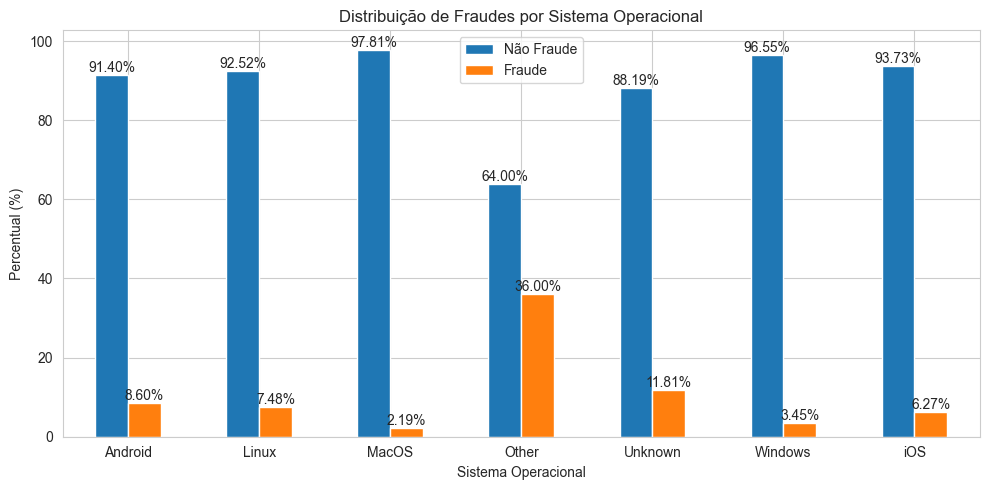

In [ ]:
# 3.6.2 Analisando a relação entre OS_Group e isFraud
os_fraud = pd.crosstab(
    identify_df["OS_Group"],
    identify_df["isFraud"],
    normalize="index"
) * 100

os_fraud.columns = [
    "Não Fraude",
    "Fraude"
]

ax = os_fraud.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Distribuição de Fraudes por Sistema Operacional")
plt.xlabel("Sistema Operacional")
plt.ylabel("Percentual (%)")

plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.show()

#### 3.7 Distribuição de Fraude por Browser

In [ ]:
# 3.7.1 Agregando a variável id_31 (navegador) em grupos mais amplos
def simplify_browser(x):
    
    if pd.isna(x):
        return "Unknown"
    
    x = str(x).lower()
    
    if "chrome" in x:
        return "Chrome"
    
    elif "safari" in x:
        return "Safari"
    
    elif "firefox" in x:
        return "Firefox"
    
    elif "edge" in x:
        return "Edge"
    
    elif "ie" in x or "trident" in x:
        return "Internet Explorer"
    
    elif "opera" in x:
        return "Opera"
    
    else:
        return "Other"


identify_df["Browser_Group"] = (
    identify_df["id_31"]
    .apply(simplify_browser)
)

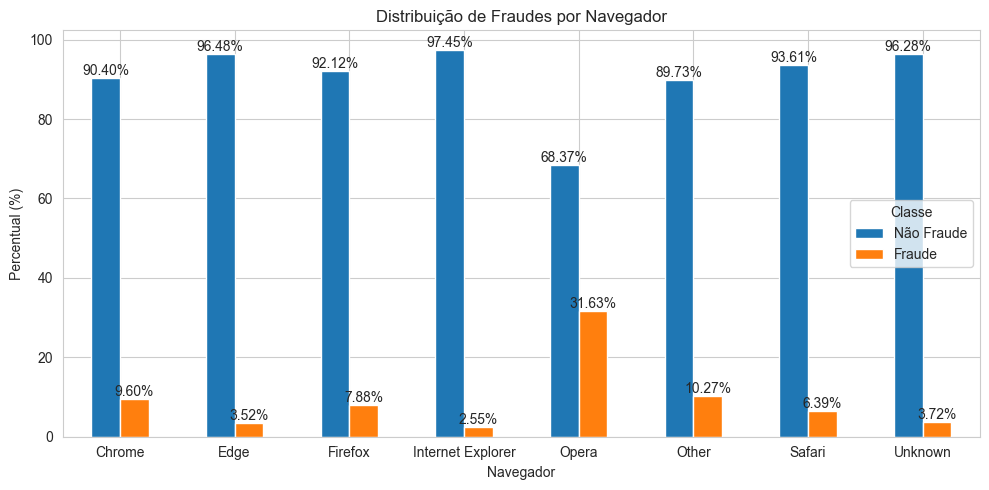

In [ ]:
# 3.7.2 Analisando a relação entre Browser_Group e isFraud
# Crosstab com percentuais
browser_fraud = pd.crosstab(
    identify_df["Browser_Group"],
    identify_df["isFraud"],
    normalize="index"
) * 100

# Renomeando colunas
browser_fraud.columns = [
    "Não Fraude",
    "Fraude"
]

# Criando gráfico
ax = browser_fraud.plot(
    kind="bar",
    figsize=(10,5)
)

# Títulos
plt.title("Distribuição de Fraudes por Navegador")
plt.xlabel("Navegador")
plt.ylabel("Percentual (%)")

# Ajustando rotação
plt.xticks(rotation=0)

# Valores nas barras
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.legend(title="Classe")

plt.tight_layout()
plt.show()